In [1]:
from pinballrt.dust import Dust, load, suggest_opacity_sampling
import astropy.units as u
import numpy as np

from scipy.interpolate import interp1d

/Users/psheehan/pinball-rt/pinballrt/dust.py:83: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if hasattr(self, dim) and getattr(self, dim) is not None and getattr(self, dim) is not ():


In [2]:
data = np.load("../pinballrt/tests/data/diana_wice.npz")
               
lam = np.logspace(np.log10(data["lam"].min()), np.log10(data["lam"].max()), 1000)*u.cm
kabs = 10.**interp1d(np.log10(data["lam"]), np.log10(data["kabs"]), kind="linear", axis=-1)(np.log10(lam.value))*u.cm**2/u.g
ksca = 10.**interp1d(np.log10(data["lam"]), np.log10(data["ksca"]), kind="linear", axis=-1)(np.log10(lam.value))*u.cm**2/u.g

p, amax = np.meshgrid(data["p"], data["amax"], indexing="ij")
amax *= u.cm

# Create the Dust object.
d = Dust(lam=lam, 
         amax=amax.flatten(), 
         p=p.flatten(), 
         kabs=kabs.reshape((-1, lam.size)),
         ksca=ksca.reshape((-1, lam.size)))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/psheehan/.pyenv/versions/anaconda3-2023.07-2/envs/pinball/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/Users/psheehan/.pyenv/versions/anaconda3-2023.07-2/envs/pinball/lib/python3.13/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /Users/psheehan/pinball-rt/examples/kabs_lightning_logs exists and is not empty.

  | Name  | Type                 | Params | Mode 
-----------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/psheehan/.pyenv/versions/anaconda3-2023.07-2/envs/pinball/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Users/psheehan/.pyenv/versions/anaconda3-2023.07-2/envs/pinball/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.
/Users/psheehan/.pyenv/versions/anaconda3-2023.07-2/envs/pinball/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.08891521394252777
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
p: 4.300000190734863, log10_amax: -2.0508475303649902, 
0.084745884 3.5422692 0.5243183
52000
nan nan
[ 3.7       -2.6440678  0.4768207] [ 4.5       -1.3728814  6.476821 ]
[ 4.30000019 -2.05084753  0.4768207 ] [ 4.30000019 -2.05084753  6.47682071]


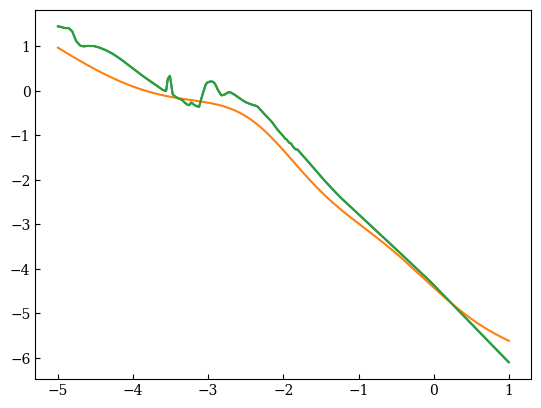

In [3]:
#for model in ["kabs", "ksca", "pmo", "random_nu"]:
for model in ["kabs"]:
    if model in ["kabs", "ksca", "pmo"]:
        d.learn(model=model, hidden_units=(16,)*6, overwrite=True)
        batch_size = 100
    else:
        d.learn(model=model, hidden_units=(48,)*3, overwrite=True)
        batch_size = 1000

    d.fit(epochs=5, batch_size=batch_size)
    d.test_model(plot=True)

In [4]:
d.plot_opacity_model()

p: 3.299999952316284, log10_amax: -3.0677967071533203, 
2.1945422 6.825687 2.815976
1000


QhullError: QH6013 qhull input error: input is less than 4-dimensional since all points have the same x coordinate 1.581

While executing:  | qhull d Qc Qt Qbb Qz Q12
Options selected for Qhull 2020.2.r 2020/08/31:
  run-id 1291836128  delaunay  Qcoplanar-keep  Qtriangulate  Qbbound-last
  Qz-infinity-point  Q12-allow-wide  _pre-merge  _zero-centrum  Qinterior-keep
  Pgood  _max-width 3.5  Error-roundoff 3.5e-15  _one-merge 3.1e-14
  Visible-distance 2.1e-14  U-max-coplanar 2.1e-14  Width-outside 4.2e-14
  _wide-facet 1.3e-13  _maxoutside 4.2e-14


p: 2.700000047683716, log10_amax: -2.3898305892944336, 


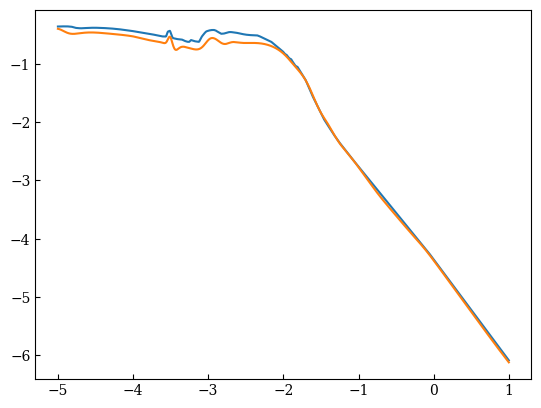

In [11]:
d.plot_opacity_model(model='kabs')

In [ ]:
d.plot_random_nu_model()

In [ ]:
from schwimmbad import MultiPool
from numpy.random import SeedSequence, seed, randint, set_state
import pandas as pd
from tqdm.auto import tqdm

pool = MultiPool(initializer=tqdm.set_lock, initargs=(tqdm.get_lock(),))

def run_dust_simulation(x):
    s, position = x
    seed(s.generate_state(1)[0])
    df = d.run_dust_simulation(nphotons=1000000, tau_range=(3., 30.), nu_range=(d.nu.min()*10000, d.nu.max()), position=position)
    return df

result = pool.map(run_dust_simulation, list(zip(SeedSequence(12345).spawn(pool.size), range(pool.size))))

df = pd.concat(result, axis=0)

In [ ]:
df.to_csv("sim_results.csv")

In [ ]:
d.learn(model='ml_step', nsamples=16000000, hidden_units=((128, 128),)*6)

In [ ]:
d.fit(epochs=100, batch_size=10000)

In [ ]:
d.test_model(plot=True)

In [ ]:
import astropy.units as u
d.plot_specific_ml_step(tau=1.5, temperature=600*u.K, nu=3e5*u.GHz, nsamples=100000, plot_columns=np.array(["log10_nu"]))

In [ ]:
d.save("dust.dst")